# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3c9fb1ad0353b4e0e4c17dbb2513c9b657090866e8cfc6fafe593021837a1502
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [3]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답:원래 데이터 주변에 작은 변화를 주어 유사한 샘플을 생성하고, 생성된 샘플에 대해 원래 모델 예측값 확인합니다. 선형 모델을 학습해 원래 모델을 근사하고,
각 특징(feature)의 영향력을 평가합니다.

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답: 원래 복잡한 모델은 간단한 선형 모델로 근사해 특징 중요도를 제공합니다.

---

#2. SHAP

In [5]:
!pip install shap

### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


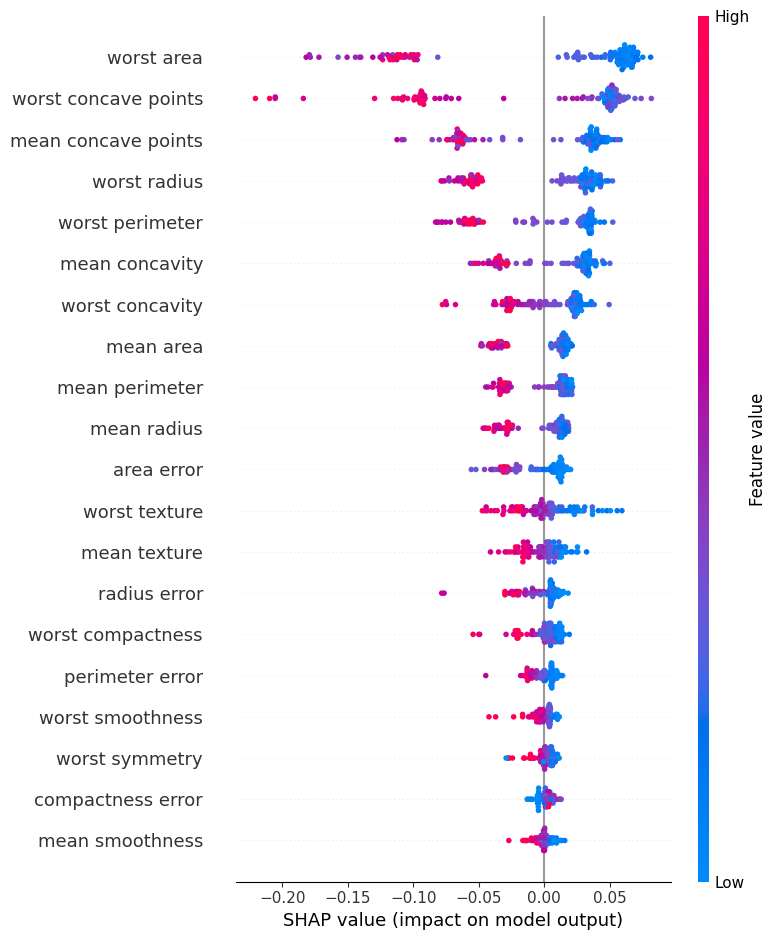

In [6]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답:양수면 해당 특성이 예측결과를 증가시키는 방향으로 기여하고, 음수면 해당 특성이 예측 결과를 감소시키는 방향으로 기여합니다.


Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답: SHAP는 모델 전역과 샘플 수준 기여도를 모두 고려하지만, Tree FI는 단순 분할 기준으로 중요도를 계산합니다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 121MB/s]


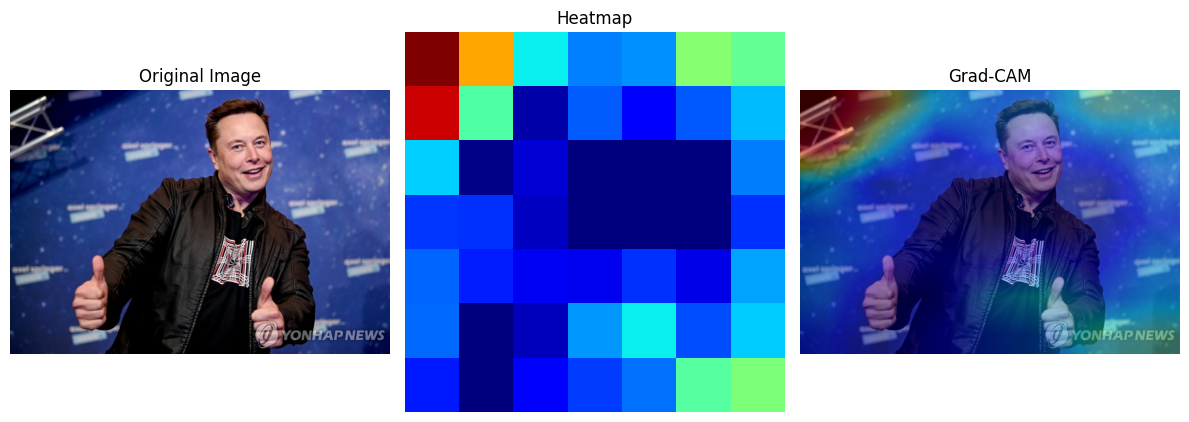

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답: 특징 맵의 공간 정보와 의미적 정보가 모두 남아있기 때문입니다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답:모델이 결정에 가장 크게 기여한 부분입니다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답: 꼭 그렇지는 않고, 모델이 잘못된 패턴이나 배경에 주목할 수도 있기 때문입니다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [10]:
# 이미지 로드 및 전처리
url = 'https://blog.kakaocdn.net/dna/cyD9pn/btsOxFfpiiW/AAAAAAAAAAAAAAAAAAAAAFGiOvHL_qlCUiUiUIg1JagJFnkaarNn8GiOBCO__hEp/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1774969199&allow_ip=&allow_referer=&signature=yWd4YCmf%2B1q9tAkMCHkW0O6PyJQ%3D'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7e69e64604a0>

In [ ]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

In [ ]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [ ]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [ ]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [ ]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

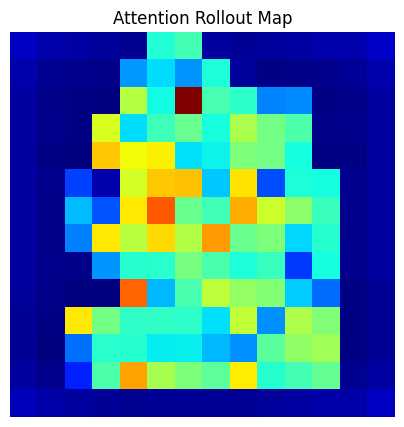

In [ ]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



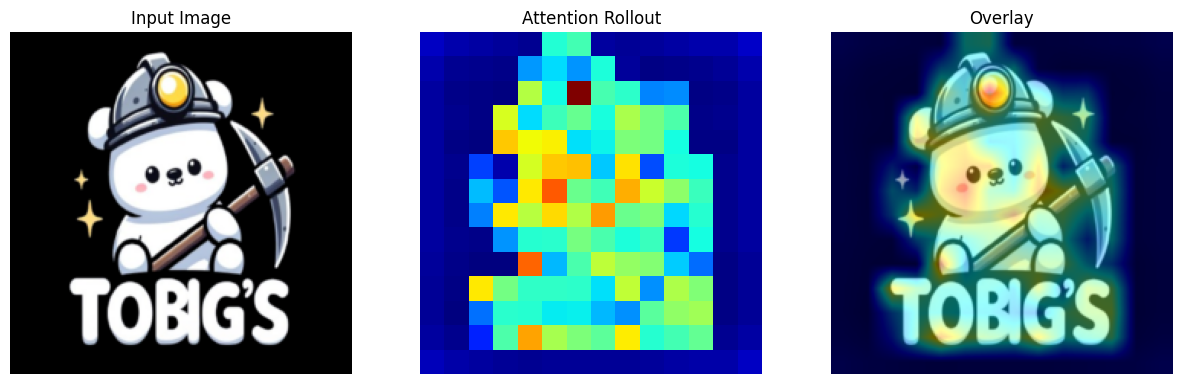

In [ ]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답: 단일 층의 Attention만 보는 것이 아니라, 모든 층의 Attention을 누적해 모델 전체의 정보 흐름을 반영하기 위해서입니다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답: Score가 높은 token/patch를 중요 특징으로 선택하여 downstream task나 discriminative feature로 활용하는 방법 등이 있을 것 같습니다.